<a href="https://colab.research.google.com/github/NK-cloud-hub/testrepo/blob/main/EDA_1st_file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
%matplotlib inline

In [ ]:
# Load the dataset
df = pd.read_csv("df_recipe_performance_machine1.csv")

In [ ]:
# Convert timestamp column to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
# Set timestamp as index for time-based analysis
df.set_index("timestamp", inplace=True)

In [ ]:
# Show basic info and statistics
print(df.info())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7769 entries, 2024-01-29 09:00:00+00:00 to 2025-03-31 23:00:00+00:00
Data columns (total 31 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   availability                      7769 non-null   float64
 1   operationalavailability           7769 non-null   float64
 2   efficiency                        7769 non-null   float64
 3   oee                               7769 non-null   float64
 4   qualityrate                       7769 non-null   float64
 5   runningtime                       7769 non-null   int64  
 6   mtbf                              7769 non-null   float64
 7   mttr                              7769 non-null   float64
 8   rejectionrate                     7769 non-null   float64
 9   processed                         7769 non-null   int64  
 10  produce                           7769 non-null   int64  
 11  workingtime          

In [ ]:
print("\nDescriptive Statistics:\n", df.describe())


Descriptive Statistics:
        availability  operationalavailability   efficiency          oee  \
count   7769.000000              7769.000000  7769.000000  7769.000000   
mean      88.317697                46.604455    50.126032    45.427297   
std       26.457847                26.086508    26.606300    25.838249   
min        0.000000                 0.000000     0.000000     0.000000   
25%       92.501103                27.277778    32.381321    26.520370   
50%      100.000000                51.583333    55.108867    49.801852   
75%      100.000000                66.777778    70.132576    64.890741   
max      100.000000               100.000000   100.000000   100.000000   

       qualityrate  runningtime         mtbf         mttr  rejectionrate  \
count       7769.0  7769.000000  7769.000000  7769.000000         7769.0   
mean         100.0  1641.239542  1421.997224    59.524839            0.0   
std            0.0   940.308159   967.186939   207.063170            0.0   
min

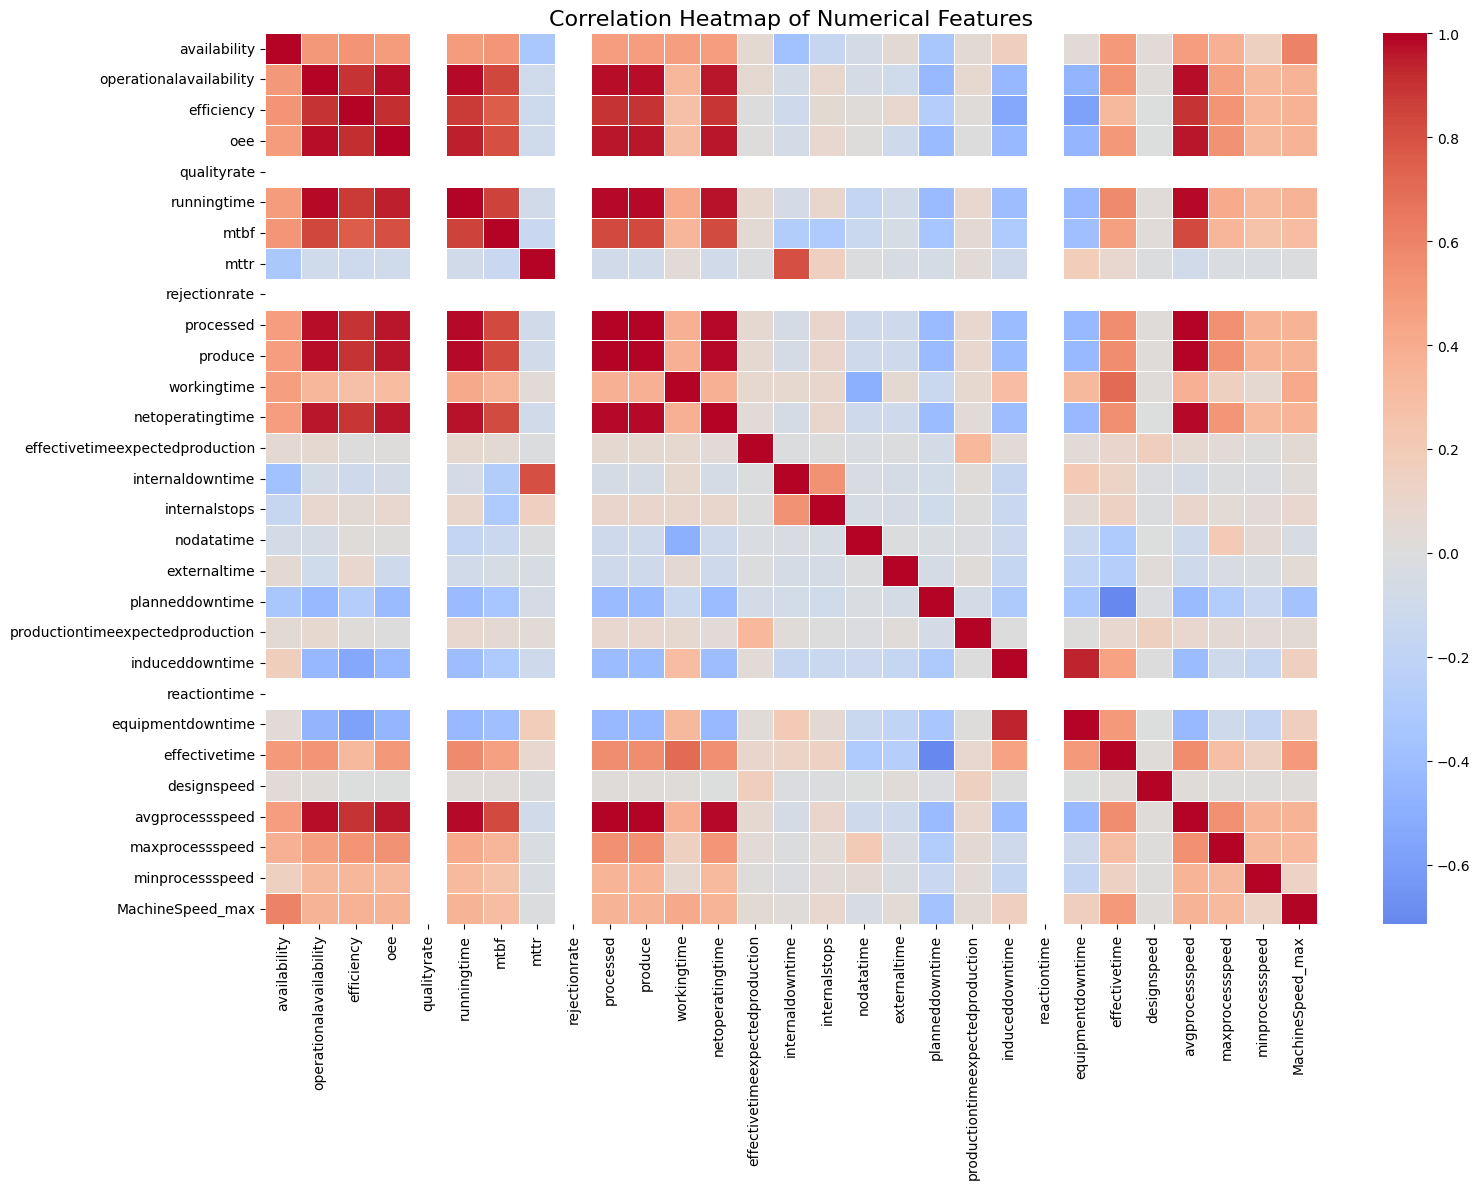

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(df.drop(columns=["recipe", "rank"]).corr(),
            cmap="coolwarm", center=0, annot=False, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

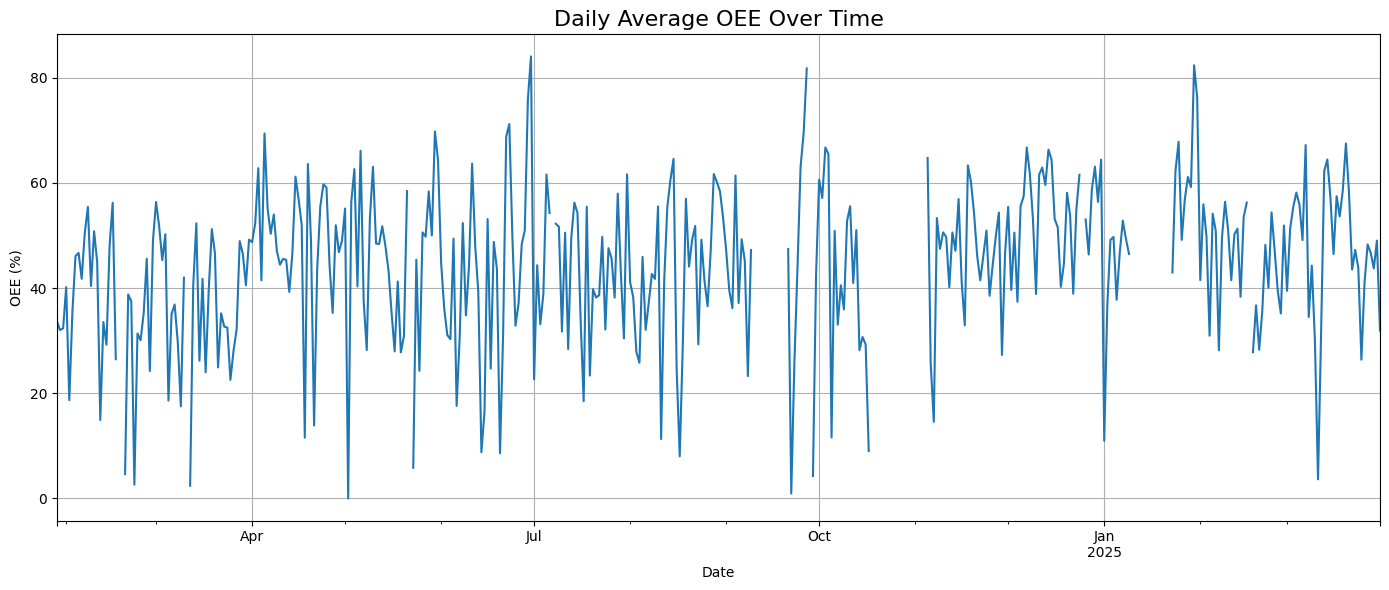

In [ ]:
# OEE(overall equipment effectiveness) Trend Over Time
oee_daily = df["oee"].resample("D").mean()

plt.figure(figsize=(14, 6))
oee_daily.plot()
plt.title("Daily Average OEE Over Time", fontsize=16)
plt.ylabel("OEE (%)")
plt.xlabel("Date")
plt.grid(True)
plt.tight_layout()
plt.show()

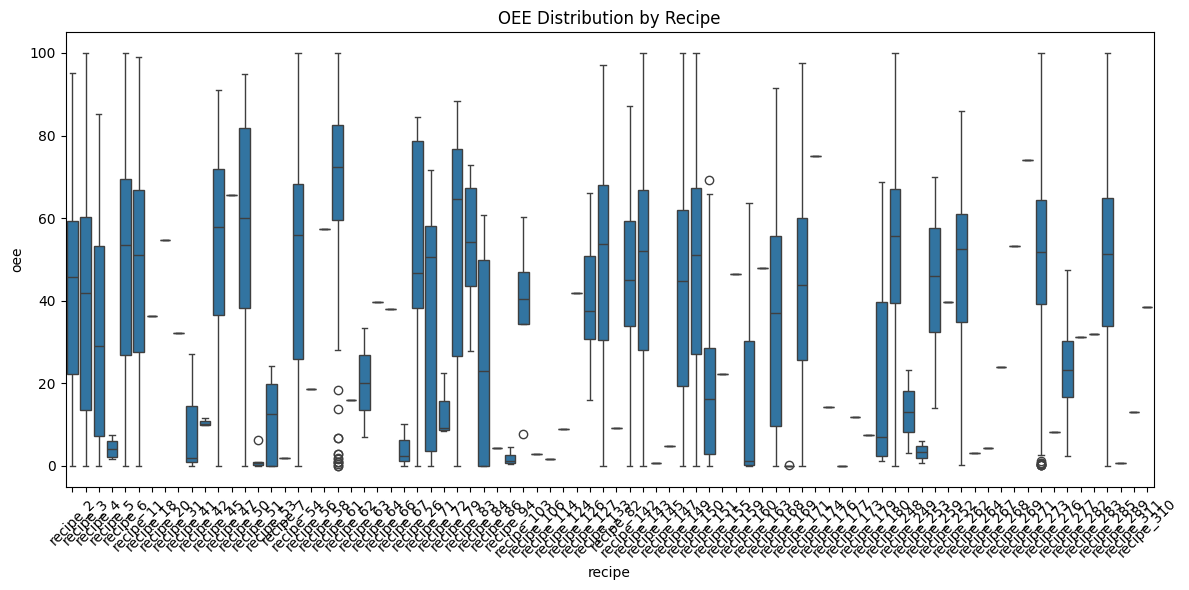

In [ ]:
# Boxplot: OEE by Recipe
plt.figure(figsize=(12, 6))
sns.boxplot(x="recipe", y="oee", data=df.reset_index())
plt.title("OEE Distribution by Recipe")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

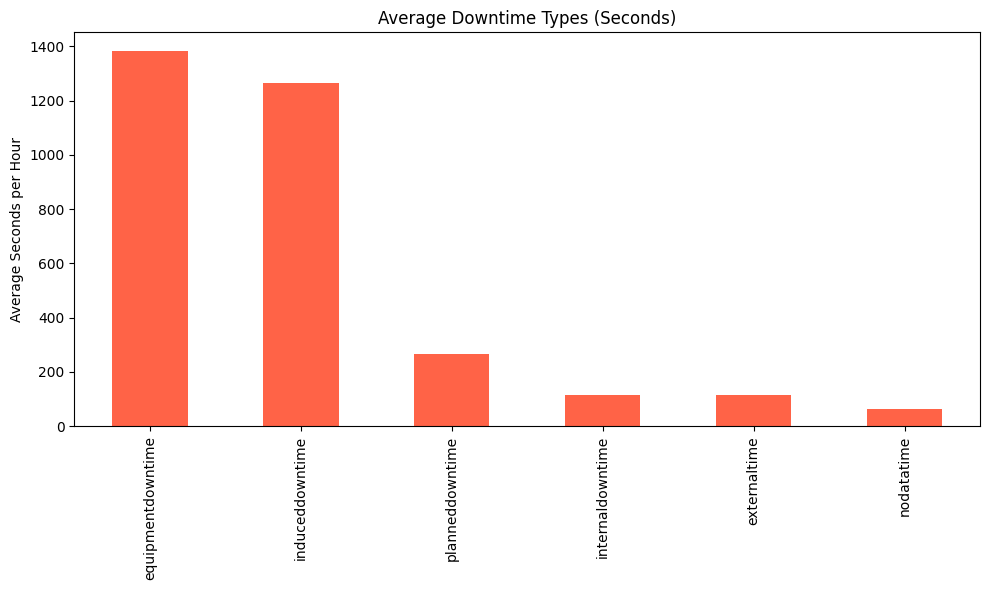

In [ ]:
# Downtime Composition
downtime_cols = [
    "equipmentdowntime",
    "internaldowntime",
    "induceddowntime",
    "planneddowntime",
    "externaltime",
    "nodatatime"
]

downtime_sum = df[downtime_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
downtime_sum.plot(kind="bar", color="tomato")
plt.title("Average Downtime Types (Seconds)")
plt.ylabel("Average Seconds per Hour")
plt.tight_layout()
plt.show()

In [ ]:
# Downtime Distribution Check
downtime_cols = ['equipmentdowntime', 'internaldowntime', 'induceddowntime',
                 'planneddowntime', 'externaltime', 'nodatatime']
print('\nDowntime Distribution (Seconds):')
print(df[downtime_cols].describe())


Downtime Distribution (Seconds):
       equipmentdowntime  internaldowntime  induceddowntime  planneddowntime  \
count        7769.000000       7769.000000      7769.000000      7769.000000   
mean         1382.289999        116.037328      1266.252671       266.330673   
std           884.359918        320.358042       877.300617       633.919065   
min             0.000000          0.000000         0.000000         0.000000   
25%           747.000000          0.000000       619.000000         0.000000   
50%          1250.000000          0.000000      1113.000000         0.000000   
75%          1897.000000         82.000000      1739.000000       189.000000   
max          3600.000000       3600.000000      3600.000000      3600.000000   

       externaltime   nodatatime  
count   7769.000000  7769.000000  
mean     114.620286    64.832153  
std      332.423674   309.542676  
min        0.000000     0.000000  
25%        0.000000     0.000000  
50%        0.000000     0.000000  


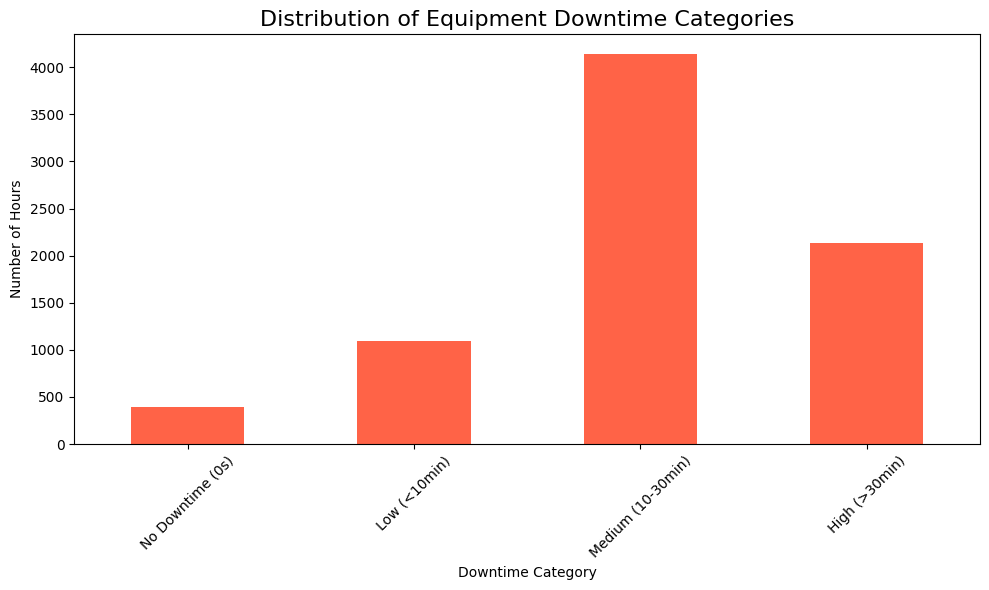

In [ ]:
# Downtime Category Distribution
df['downtime_category'] = pd.cut(df['equipmentdowntime'],
                                bins=[-1, 0, 600, 1800, float('inf')],
                                labels=['No Downtime (0s)', 'Low (<10min)', 'Medium (10-30min)', 'High (>30min)'])
downtime_category_counts = df['downtime_category'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
downtime_category_counts.plot(kind='bar', color='tomato')
plt.title('Distribution of Equipment Downtime Categories', fontsize=16)
plt.xlabel('Downtime Category')
plt.ylabel('Number of Hours')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()